# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 28     |  |
| :-------------|:-------------|
| Christoph Smit| 6494056 |
| Lieke Boontjes| 6543715 |
| Frederik Roerink| 6550223 |
| Planning Groep: 28     |10:55  |
|---|---|
| Condensator klaar | 12:30 - 12.45 |
| Sensor klaar | 17:00 - 17:30|
| groep aanwezig 1| 10.45 |
| groep aanwezig 2| 13.30 |
| Pauze 1| 15:00 - 15:10 |
| Lunch| 12:30 - 13:30 |
| Pauze 2| 16:00 - 16:10 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schets_condensator.jpeg" alt="schets student 1" width="400"/>

Dikte van het karton is 1 mm. d = 1 mm

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
epsilon_0 = 8.854187817e-12 # F/m

def capaciteit_plaatcondensator(A, d, epsr = 1.0):
    return epsilon_0 * epsr * A / d
# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C_F = [capaciteit_plaatcondensator(2.0, 0.001), capaciteit_plaatcondensator(4.7, 0.001),capaciteit_plaatcondensator(1.2, 0.001)]
C = [c * 1e12 for c in C_F] # omzetten van F naar pF

print(f"Berekende capaciteit plaatcondensator groep 28 is {C[0]:.1f} pF")
print(f"Berekende capaciteit plaatcondensator groep 28 is {C[1]:.1f} pF")
print(f"Berekende capaciteit plaatcondensator groep 28 is {C[2]:.1f} pF")

C_real = capaciteit_plaatcondensator(0.01, 0.001)
C_real_pf = C_real * 1e12 # omzetten van F naar pF
print(f"Berekende capaciteit plaatcondensator groep 28 is {C_real_pf:.1f} pF")


Berekende capaciteit plaatcondensator groep 28 is 17708.4 pF
Berekende capaciteit plaatcondensator groep 28 is 41614.7 pF
Berekende capaciteit plaatcondensator groep 28 is 10625.0 pF
Berekende capaciteit plaatcondensator groep 28 is 88.5 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](opstelling_condensator_1.jpeg)
![scope meting 2](opstelling_condensator_2.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 28| 88.5 pF |0.45 V | 0.75 V |149 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](schetsen_sensoren.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die de snelheid van een plaat meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](Schematische_opstelling_sensor.jpeg)

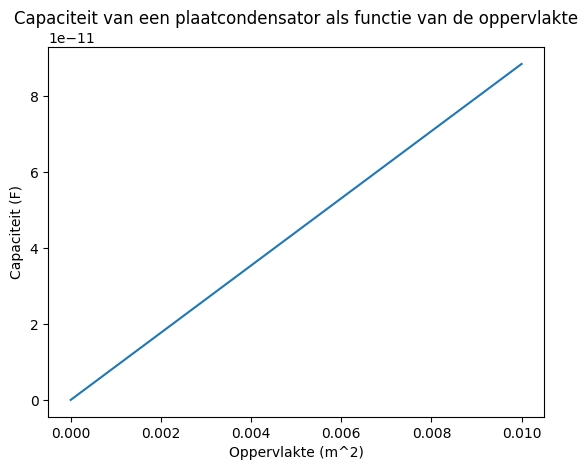

In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import numpy as np
import matplotlib.pyplot as plt 
eps = 8.85e-12 # F/m
def capacity(A, d, eps):
    return eps * A / d


A = np.linspace(0, 0.01, 100) # m^2
d= 0.001

plt.figure()
plt.plot(A, capacity(A, d, eps))
plt.xlabel("Oppervlakte (m^2)")
plt.ylabel("Capaciteit (F)")
plt.title("Capaciteit van een plaatcondensator als functie van de oppervlakte")
plt.show()



## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 0 |0 |
| gemiddelde capaciteit| 75 |752 |
| maximale capaciteit| 150 |1498 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](opstelling_scope1.jpeg)
![meting 1](opstelling_scope2.jpeg)
![meting 2](opstelling_scope3.jpeg)
![meting 2](opstelling_scope4.jpeg)

## Opdracht 7: Plot de kalibratiegrafiek.

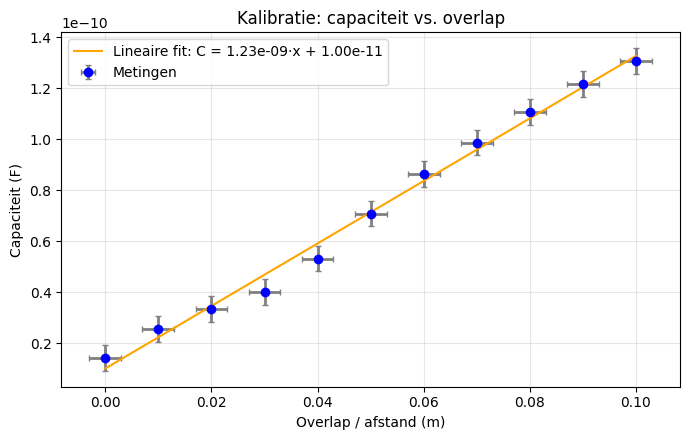

Lineaire fit parameters: a = 1.22636e-09 F/m, b = 1.00364e-11 F


In [4]:
# Data
metingen = np.array([14.2, 25.5, 33.3, 40.1, 53.1, 70.8, 86.4, 98.6, 110.6, 121.7, 130.6]) # pF
afstand = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]) # cm

# Meetfout
afstand_fout = 0.3 # cm
metingen_fout = 5 # pF

# Conversie
metingen_F = metingen * 1e-12 # omzetten van pF naar F
afstand_m = afstand * 1e-2 # omzetten van cm naar m

# Lineaire fit: C = a*x + b
a, b = np.polyfit(afstand_m, metingen_F, 1)

# Fit-curve 
x_fit = np.linspace(afstand_m.min(), afstand_m.max(), 200)
y_fit = a * x_fit + b

# Plot
plt.figure(figsize=(7, 4.5))
plt.errorbar(afstand_m, metingen_F, xerr=afstand_fout*1e-2, yerr=metingen_fout*1e-12, fmt='o', label="Metingen", color="blue", ecolor="gray", elinewidth=2, capsize=2)
plt.plot(x_fit, y_fit, label=f"Lineaire fit: C = {a:.2e}·x + {b:.2e}", color="orange")

plt.xlabel("Overlap / afstand (m)")
plt.ylabel("Capaciteit (F)")
plt.title("Kalibratie: capaciteit vs. overlap")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(f"Lineaire fit parameters: a = {a:.5e} F/m, b = {b:.5e} F")

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* We meten nu door één van de platen van één kant langzaam over de andere plaat te schuiven. Na het punt waar de platen precies op elkaar liggen, daalt de grafiek van de capaciteit tegen de overlap echter weer. Dit zou resulteren in een negatieve snelheid, terwijl de plaat nog steeds dezelfde kant op beweegt. Dat klopt niet. Om dit te verbeteren moet de code worden aangepast zodat de berekende snelheid altijd positief geprint wordt.
* We duwen nu handmatig de bewegende plaat in één richting over de andere plaat. Echter kunnen bewegingen in de andere richtingen zorgen voor een foutieve snelheid in de gewenste richting. Daarom moet er een soort rails/baan gemaakt worden zodat de bewegende plaat maar over één as kan bewegen. 

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](final_opstelling1.jpeg)
![foto sensor](final_opstelling2.jpeg)

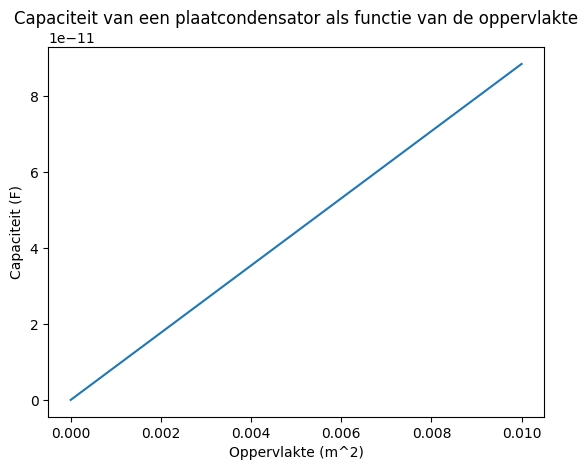

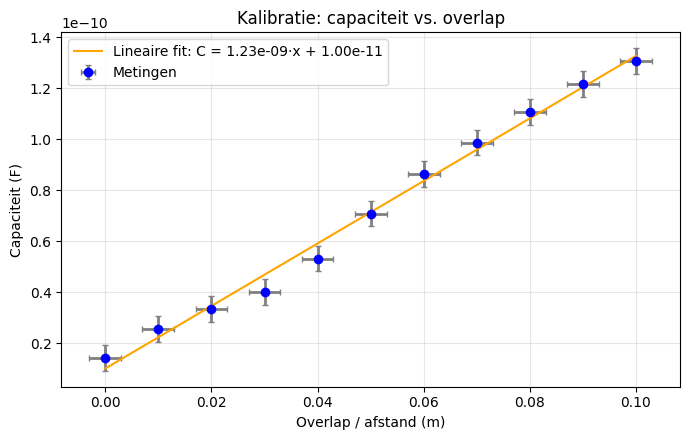

Lineaire fit parameters: a = 1.22636e-09 F/m, b = 1.00364e-11 F


In [5]:
# Ontwerpgrafiek 
eps = 8.85e-12 # F/m
def capacity(A, d, eps):
    return eps * A / d


A = np.linspace(0, 0.01, 100) # m^2
d= 0.001

plt.figure()
plt.plot(A, capacity(A, d, eps))
plt.xlabel("Oppervlakte (m^2)")
plt.ylabel("Capaciteit (F)")
plt.title("Capaciteit van een plaatcondensator als functie van de oppervlakte")
plt.show()

# Data
metingen = np.array([14.2, 25.5, 33.3, 40.1, 53.1, 70.8, 86.4, 98.6, 110.6, 121.7, 130.6]) # pF
afstand = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]) # cm

# Meetfout
afstand_fout = 0.3 # cm
metingen_fout = 5 # pF

# Conversie
metingen_F = metingen * 1e-12 # omzetten van pF naar F
afstand_m = afstand * 1e-2 # omzetten van cm naar m

# Lineaire fit: C = a*x + b
a, b = np.polyfit(afstand_m, metingen_F, 1)

# Fit-curve 
x_fit = np.linspace(afstand_m.min(), afstand_m.max(), 200)
y_fit = a * x_fit + b

# Plot
plt.figure(figsize=(7, 4.5))
plt.errorbar(afstand_m, metingen_F, xerr=afstand_fout*1e-2, yerr=metingen_fout*1e-12, fmt='o', label="Metingen", color="blue", ecolor="gray", elinewidth=2, capsize=2)
plt.plot(x_fit, y_fit, label=f"Lineaire fit: C = {a:.2e}·x + {b:.2e}", color="orange")

plt.xlabel("Overlap / afstand (m)")
plt.ylabel("Capaciteit (F)")
plt.title("Kalibratie: capaciteit vs. overlap")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(f"Lineaire fit parameters: a = {a:.5e} F/m, b = {b:.5e} F")

Voor de conversie van deze parameters naar de snelheid is de code in Arduino geschreven: 

In [6]:
""" 
float Cx = (AvgVal * Cref) / (float)(ADCmax - AvgVal) -C_offset;
float Afstand = (Cx*1e-12 - 1.00364e-11)/1.22636e-9 ; //Afstand berekenen die de bovenste plaat op de onderste ligt via formule gevonden bij kalibratie
float Snelheid = fabs((Afstand - vorige_afstand) / 0.2); //Snelheid hieruit berekenen, er wordt gemeten elke 200 ms vandaar delen door 0.2
//send result to PC via USB comport:
Serial.print(Cx, 1);// send Cx value, 1 digit behind the comma (giving 0.1pF resolution)
Serial.print(" pF ");// print text: pF
Serial.println(" "); //send linefeed to start new line
Serial.print(Snelheid, 2); //Printen snelheid
Serial.print(" m/s ");// print text: m/s
Serial.println(" "); //send linefeed to start new line
vorige_afstand = Afstand; //Huidige afstand als vorige
"""

' \nfloat Cx = (AvgVal * Cref) / (float)(ADCmax - AvgVal) -C_offset;\nfloat Afstand = (Cx*1e-12 - 1.00364e-11)/1.22636e-9 ; //Afstand berekenen die de bovenste plaat op de onderste ligt via formule gevonden bij kalibratie\nfloat Snelheid = fabs((Afstand - vorige_afstand) / 0.2); //Snelheid hieruit berekenen, er wordt gemeten elke 200 ms vandaar delen door 0.2\n//send result to PC via USB comport:\nSerial.print(Cx, 1);// send Cx value, 1 digit behind the comma (giving 0.1pF resolution)\nSerial.print(" pF ");// print text: pF\nSerial.println(" "); //send linefeed to start new line\nSerial.print(Snelheid, 2); //Printen snelheid\nSerial.print(" m/s ");// print text: m/s\nSerial.println(" "); //send linefeed to start new line\nvorige_afstand = Afstand; //Huidige afstand als vorige\n'

## Opdracht 10: Vul hieronder de conclusie in.

De sensor is redelijk geschikt om de snelheid van een object ten opzicht van een stationaire plaat te meten. Echter kan er geen richting aan deze snelheid gebonden worden. De sensor geeft enkel de absolute snelheid van het object. 
De rail uit de verbeteringen zou voor meer nauwkeurigheid moeten leiden, echter bleek dat met onze middelen (ductape en sateprikkers) de nauwkeurig eerder toenam door de stukken tape op de baan. Ook bleek dat er, ondanks de toevoegde code zodat de snelheid altijd positief is, niks te zeggen valt over de richting van het object.
Er zit weinig verschil tussen de ontwerpgrafiek en de werkelijke grafiek. Echter bleek dat onze grafiek niet door de oorsprong gaat, zoals wel was verwacht bij het ontwerp. Dit valt te verklaren aan de aanwezigheid van een offset in de meetinstrumenten en opstelling. Deze offset is echter niet van enorme waarde, 1.00e-11 F.
Het verband van de formule bleek te kloppen, echter bleek dat we er in de theorie met een factor van 2 naast de capaciteit zaten.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

In de formule van de capaciteit staat de oppervlakte recht evenredig met de capaciteit. We verwachten daarom een lineaire lijn te zien met richtingscoëfficient $\frac{\epsilon}{d}$. Ook gaat de capaciteit door het punt (0,0), omdat er geen capaciteit is als er geen overlappende oppervlakte is.

![foto sensor](final_opstelling1.jpeg)
![oscilloscoop](opstelling_condensator_2.jpeg)
![foto sensor](Schematische_opstelling_sensor.jpeg)


LTspice simulatie:

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 0 |0 |
| gemiddelde capaciteit| 75 |752 |
| maximale capaciteit| 150 |1498 |

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

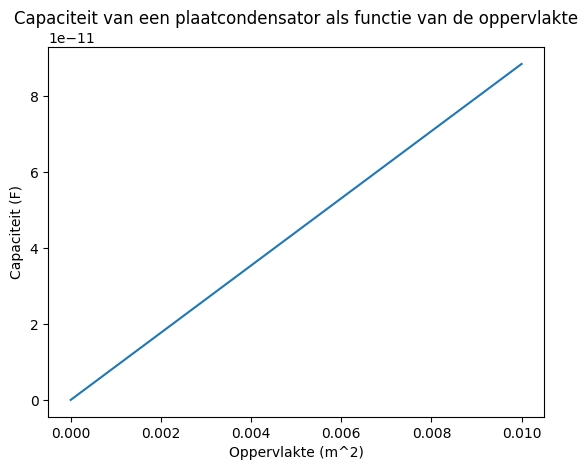

In [7]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import numpy as np
import matplotlib.pyplot as plt 
eps = 8.85e-12 # F/m
def capacity(A, d, eps):
    return eps * A / d


A = np.linspace(0, 0.01, 100) # m^2
d= 0.001

plt.figure()
plt.plot(A, capacity(A, d, eps))
plt.xlabel("Oppervlakte (m^2)")
plt.ylabel("Capaciteit (F)")
plt.title("Capaciteit van een plaatcondensator als functie van de oppervlakte")
plt.show()


kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

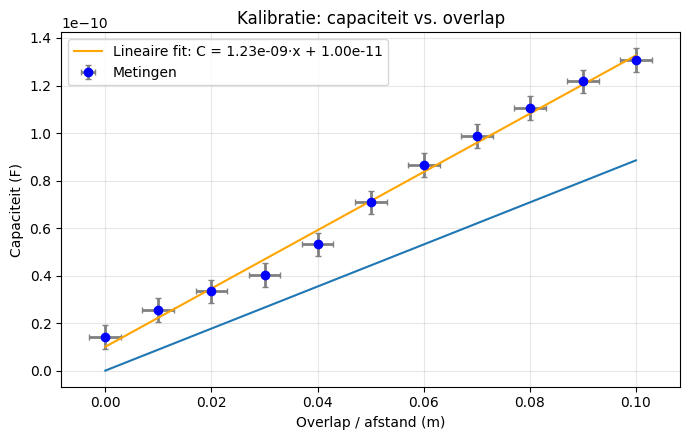

Lineaire fit parameters: a = 1.22636e-09 F/m, b = 1.00364e-11 F


In [8]:
# Ontwerpgrafiek 
eps = 8.85e-12 # F/m
def capacity(A, d, eps):
    return eps * A*0.1 / d


A = np.linspace(0, 0.1, 100) # m^2
d= 0.001



# Data
metingen = np.array([14.2, 25.5, 33.3, 40.1, 53.1, 70.8, 86.4, 98.6, 110.6, 121.7, 130.6]) # pF
afstand = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]) # cm

# Meetfout
afstand_fout = 0.3 # cm
metingen_fout = 5 # pF

# Conversie
metingen_F = metingen * 1e-12 # omzetten van pF naar F
afstand_m = afstand * 1e-2 # omzetten van cm naar m

# Lineaire fit: C = a*x + b
a, b = np.polyfit(afstand_m, metingen_F, 1)

# Fit-curve 
x_fit = np.linspace(afstand_m.min(), afstand_m.max(), 200)
y_fit = a * x_fit + b

# Plot
plt.figure(figsize=(7, 4.5))
plt.errorbar(afstand_m, metingen_F, xerr=afstand_fout*1e-2, yerr=metingen_fout*1e-12, fmt='o', label="Metingen", color="blue", ecolor="gray", elinewidth=2, capsize=2)
plt.plot(x_fit, y_fit, label=f"Lineaire fit: C = {a:.2e}·x + {b:.2e}", color="orange")
plt.plot(A, capacity(A, d, eps))
plt.xlabel("Overlap / afstand (m)")
plt.ylabel("Capaciteit (F)")
plt.title("Kalibratie: capaciteit vs. overlap")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(f"Lineaire fit parameters: a = {a:.5e} F/m, b = {b:.5e} F")

Het lineaire verband van de kalibratie is goed te zien in de grafiek. Deze grafiek gaat echter niet door nul, dat komt omdat de meting teruggaf dat de plaat ook zonder overlap nog capaciteit. Ook is onze gemeten capaciteit hoger dan de theoretisch berekende waarde. Dat zou missschien kunnen komen doordat de permittiviteit van lucht lager is dan die van karton.

In [9]:
""" 
float Cx = (AvgVal * Cref) / (float)(ADCmax - AvgVal) -C_offset;
float Afstand = (Cx*1e-12 - 1.00364e-11)/1.22636e-9 ; //Afstand berekenen die de bovenste plaat op de onderste ligt via formule gevonden bij kalibratie
float Snelheid = fabs((Afstand - vorige_afstand) / 0.2); //Snelheid hieruit berekenen, er wordt gemeten elke 200 ms vandaar delen door 0.2
//send result to PC via USB comport:
Serial.print(Cx, 1);// send Cx value, 1 digit behind the comma (giving 0.1pF resolution)
Serial.print(" pF ");// print text: pF
Serial.println(" "); //send linefeed to start new line
Serial.print(Snelheid, 2); //Printen snelheid
Serial.print(" m/s ");// print text: m/s
Serial.println(" "); //send linefeed to start new line
vorige_afstand = Afstand; //Huidige afstand als vorige
"""

' \nfloat Cx = (AvgVal * Cref) / (float)(ADCmax - AvgVal) -C_offset;\nfloat Afstand = (Cx*1e-12 - 1.00364e-11)/1.22636e-9 ; //Afstand berekenen die de bovenste plaat op de onderste ligt via formule gevonden bij kalibratie\nfloat Snelheid = fabs((Afstand - vorige_afstand) / 0.2); //Snelheid hieruit berekenen, er wordt gemeten elke 200 ms vandaar delen door 0.2\n//send result to PC via USB comport:\nSerial.print(Cx, 1);// send Cx value, 1 digit behind the comma (giving 0.1pF resolution)\nSerial.print(" pF ");// print text: pF\nSerial.println(" "); //send linefeed to start new line\nSerial.print(Snelheid, 2); //Printen snelheid\nSerial.print(" m/s ");// print text: m/s\nSerial.println(" "); //send linefeed to start new line\nvorige_afstand = Afstand; //Huidige afstand als vorige\n'